# Project 7A — Momentum Strategy Backtester (Single Asset)

## Objective
Build and backtest a momentum trading strategy on Nifty 50.
Compare risk-adjusted performance against a buy and hold benchmark.

## Strategy Logic
- Momentum signal = 20-day return
- If momentum > 0 → go long next day
- If momentum < 0 → move to cash next day
- Signal shifted by 1 day to eliminate lookahead bias
- Transaction cost = 0.1% per trade

## Results
| Metric | Strategy | Buy and Hold |
|--------|----------|--------------|
| Total Return | 79.72% | 97.06% |
| Annualised Return | 10.68% | 12.46% |
| Sharpe Ratio | 0.441 | 0.406 |
| Max Drawdown | -15.93% | -38.44% |
| Win Rate | 57.06% | N/A |
| Days in Market | 62.23% | 100% |

## Key Finding
The strategy underperforms buy and hold on raw returns in a 6 year bull market.
However it achieves a higher Sharpe ratio and reduces maximum drawdown from
38% to 16% — protecting capital dramatically during the COVID crash of 2020.
In risk-adjusted terms the momentum strategy is superior.

## Libraries
pandas, numpy, matplotlib, yfinance

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

print("All imports successful")

All imports successful


In [2]:
# Download Nifty 50 data
ticker = yf.Ticker("^NSEI")
df = ticker.history(start="2018-01-01", end="2024-01-01")

# Keep only closing price
df = df[['Close']].copy()

# Calculate daily returns
df['Returns'] = df['Close'].pct_change()

# Drop NaN
df = df.dropna()

print(f"Data shape: {df.shape}")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")
print(f"Total trading days: {len(df)}")

Data shape: (1476, 2)
Date range: 2018-01-03 to 2023-12-29
Total trading days: 1476


In [3]:
# Momentum parameters
lookback = 20  # days to measure momentum (1 trading month)

# Momentum signal = return over past lookback days
df['Momentum'] = df['Close'].pct_change(lookback)

# Generate position signal
# +1 = long (buy), 0 = out of market
df['Signal'] = np.where(df['Momentum'] > 0, 1, 0)

# Shift signal by 1 day — you see today's momentum
# but can only trade TOMORROW — no lookahead bias
df['Position'] = df['Signal'].shift(1)

# Drop NaN rows created by lookback and shift
df = df.dropna()

print(f"Data shape after signal generation: {df.shape}")
print(f"\nSignal distribution:")
print(f"Days long (in market):     {int(df['Position'].sum())} ({df['Position'].mean()*100:.1f}%)")
print(f"Days flat (out of market): {int((df['Position']==0).sum())} ({(df['Position']==0).mean()*100:.1f}%)")
print(f"\nFirst 5 rows:")
print(df.head())

Data shape after signal generation: (1456, 5)

Signal distribution:
Days long (in market):     906 (62.2%)
Days flat (out of market): 550 (37.8%)

First 5 rows:
                                  Close   Returns  Momentum  Signal  Position
Date                                                                         
2018-02-01 00:00:00+05:30  11016.900391 -0.000979  0.054935       1       0.0
2018-02-02 00:00:00+05:30  10760.599609 -0.023264  0.024351       1       1.0
2018-02-05 00:00:00+05:30  10666.549805 -0.008740  0.010200       1       1.0
2018-02-06 00:00:00+05:30  10498.250000 -0.015778 -0.011799       0       1.0
2018-02-07 00:00:00+05:30  10476.700195 -0.002053 -0.015070       0       0.0


In [4]:
# Transaction cost — 0.1% per trade (realistic for Indian markets)
transaction_cost = 0.001

# Detect trades — position changes from previous day
df['Trade'] = df['Position'].diff().abs()

# Strategy returns = position × next day return − transaction cost when trading
df['Strategy_Returns'] = (df['Position'] * df['Returns']) - (df['Trade'] * transaction_cost)

# Buy and hold returns — always invested, no trading
df['BuyHold_Returns'] = df['Returns']

# Cumulative returns
df['Strategy_Cumulative'] = (1 + df['Strategy_Returns']).cumprod()
df['BuyHold_Cumulative'] = (1 + df['BuyHold_Returns']).cumprod()

print(f"Total trades made: {int(df['Trade'].sum())}")
print(f"Total transaction cost drag: {(df['Trade'] * transaction_cost).sum()*100:.3f}%")
print(f"\nFinal cumulative returns:")
print(f"Strategy:     {(df['Strategy_Cumulative'].iloc[-1]-1)*100:.2f}%")
print(f"Buy and Hold: {(df['BuyHold_Cumulative'].iloc[-1]-1)*100:.2f}%")

Total trades made: 131
Total transaction cost drag: 13.100%

Final cumulative returns:
Strategy:     79.72%
Buy and Hold: 97.06%


In [5]:
# ── Sharpe Ratio ──────────────────────────────────────────
# Annualised Sharpe = (mean daily return / std daily return) × √252
# 252 = trading days in a year
# Risk free rate ≈ 6% annual = 6/252 daily for India

risk_free_daily = 0.06 / 252

strategy_excess = df['Strategy_Returns'] - risk_free_daily
buyhold_excess  = df['BuyHold_Returns']  - risk_free_daily

sharpe_strategy = (strategy_excess.mean() / strategy_excess.std()) * np.sqrt(252)
sharpe_buyhold  = (buyhold_excess.mean()  / buyhold_excess.std())  * np.sqrt(252)

# ── Max Drawdown ───────────────────────────────────────────
# Drawdown = how much you fell from your peak at any point
def max_drawdown(cumulative_returns):
    rolling_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - rolling_max) / rolling_max
    return drawdown.min()

mdd_strategy = max_drawdown(df['Strategy_Cumulative'])
mdd_buyhold  = max_drawdown(df['BuyHold_Cumulative'])

# ── Win Rate ───────────────────────────────────────────────
# % of trading days where strategy made money
strategy_wins = (df[df['Position'] == 1]['Strategy_Returns'] > 0).mean()

# ── Annualised Return ──────────────────────────────────────
n_years = len(df) / 252

ann_return_strategy = (df['Strategy_Cumulative'].iloc[-1]) ** (1/n_years) - 1
ann_return_buyhold  = (df['BuyHold_Cumulative'].iloc[-1])  ** (1/n_years) - 1

# ── Print All Metrics ──────────────────────────────────────
print("=" * 50)
print("       STRATEGY PERFORMANCE REPORT")
print("=" * 50)
print(f"\n{'Metric':<30} {'Strategy':>10} {'Buy&Hold':>10}")
print("-" * 50)
print(f"{'Total Return':<30} {df['Strategy_Cumulative'].iloc[-1]-1:>9.2%} {df['BuyHold_Cumulative'].iloc[-1]-1:>9.2%}")
print(f"{'Annualised Return':<30} {ann_return_strategy:>9.2%} {ann_return_buyhold:>9.2%}")
print(f"{'Sharpe Ratio':<30} {sharpe_strategy:>10.3f} {sharpe_buyhold:>10.3f}")
print(f"{'Max Drawdown':<30} {mdd_strategy:>9.2%} {mdd_buyhold:>9.2%}")
print(f"{'Win Rate (trading days)':<30} {strategy_wins:>9.2%} {'N/A':>10}")
print(f"{'Total Trades':<30} {int(df['Trade'].sum()):>10} {'0':>10}")
print(f"{'Days in Market':<30} {df['Position'].mean():>9.2%} {'100.00%':>10}")
print("=" * 50)

       STRATEGY PERFORMANCE REPORT

Metric                           Strategy   Buy&Hold
--------------------------------------------------
Total Return                      79.72%    97.06%
Annualised Return                 10.68%    12.46%
Sharpe Ratio                        0.441      0.406
Max Drawdown                     -15.93%   -38.44%
Win Rate (trading days)           57.06%        N/A
Total Trades                          131          0
Days in Market                    62.23%    100.00%


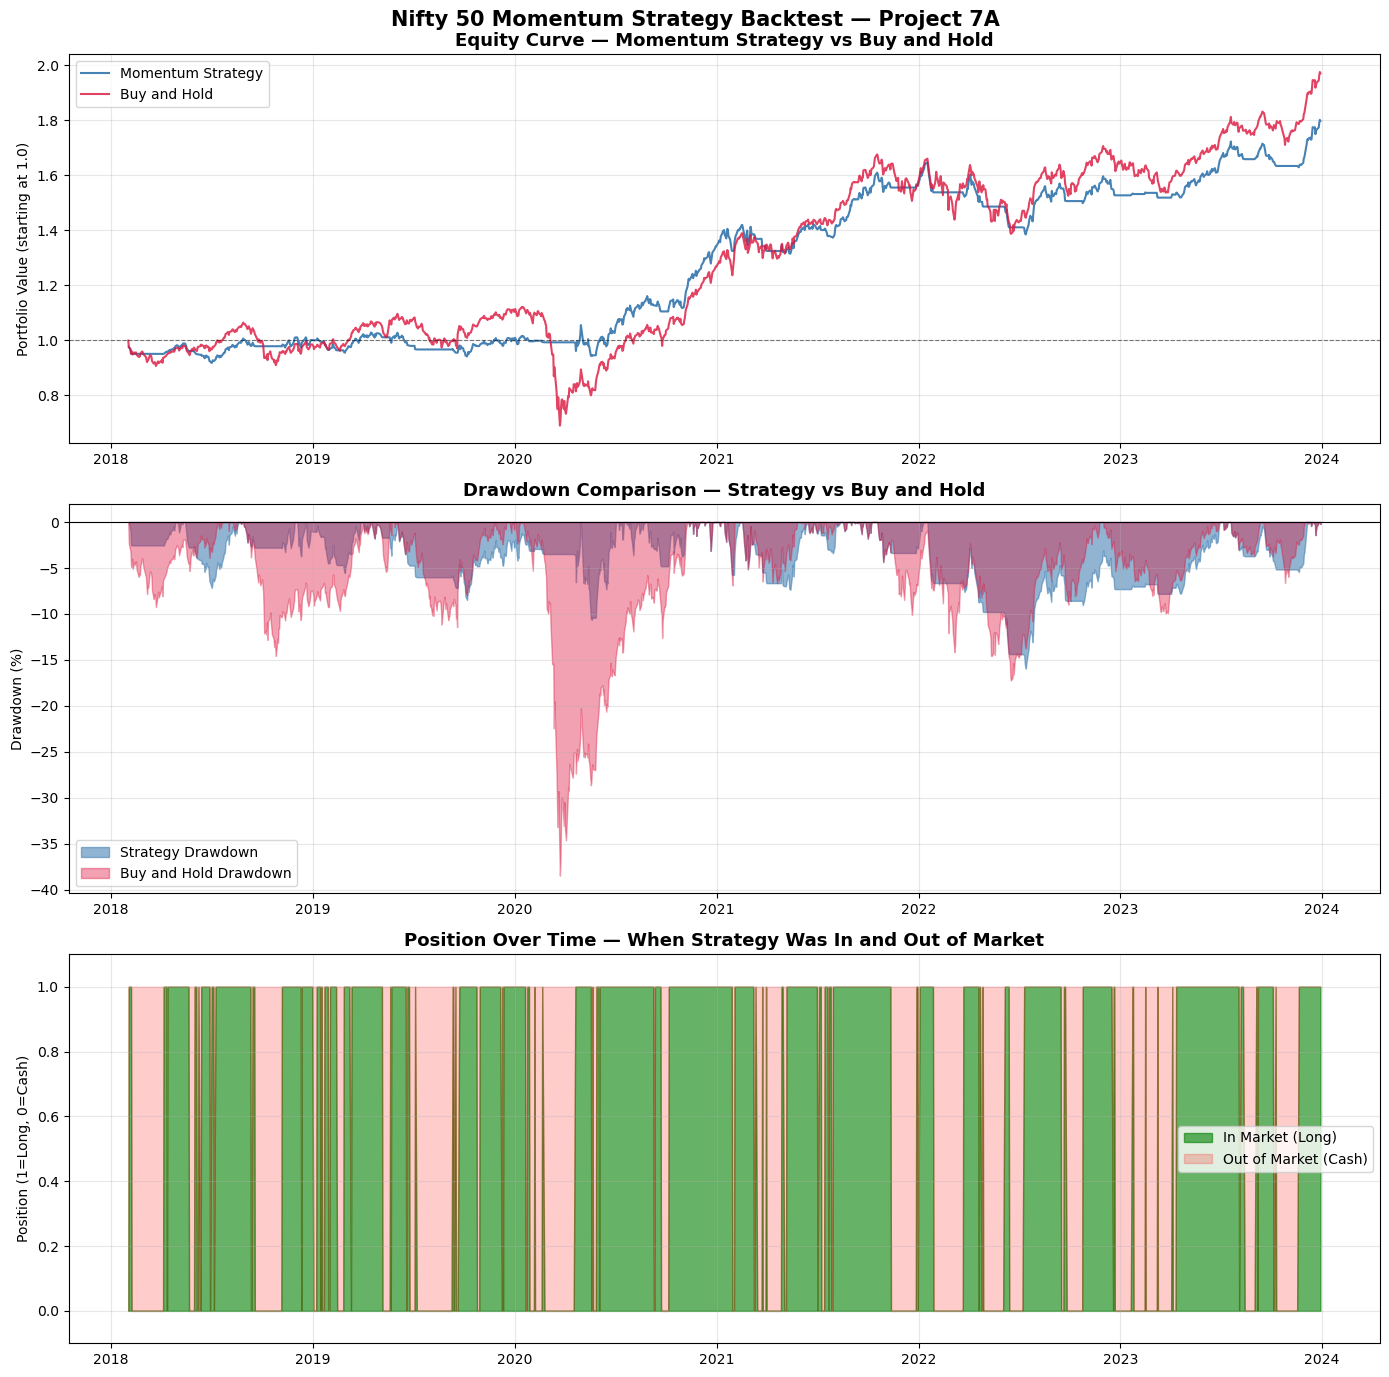

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

# ── Plot 1 — Equity Curve ──────────────────────────────────
ax1 = axes[0]
ax1.plot(df.index, df['Strategy_Cumulative'], 
         color='steelblue', linewidth=1.5, label='Momentum Strategy')
ax1.plot(df.index, df['BuyHold_Cumulative'], 
         color='crimson', linewidth=1.5, label='Buy and Hold', alpha=0.8)
ax1.set_title('Equity Curve — Momentum Strategy vs Buy and Hold', 
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Portfolio Value (starting at 1.0)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(y=1.0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

# ── Plot 2 — Drawdown ──────────────────────────────────────
def drawdown_series(cumulative):
    rolling_max = cumulative.cummax()
    return (cumulative - rolling_max) / rolling_max

ax2 = axes[1]
ax2.fill_between(df.index, drawdown_series(df['Strategy_Cumulative']) * 100,
                 alpha=0.6, color='steelblue', label='Strategy Drawdown')
ax2.fill_between(df.index, drawdown_series(df['BuyHold_Cumulative']) * 100,
                 alpha=0.4, color='crimson', label='Buy and Hold Drawdown')
ax2.set_title('Drawdown Comparison — Strategy vs Buy and Hold',
              fontsize=13, fontweight='bold')
ax2.set_ylabel('Drawdown (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linewidth=0.8)

# ── Plot 3 — Position Over Time ────────────────────────────
ax3 = axes[2]
ax3.fill_between(df.index, df['Position'],
                 alpha=0.6, color='green', label='In Market (Long)')
ax3.fill_between(df.index, df['Position'],  1,
                 alpha=0.2, color='red', label='Out of Market (Cash)')
ax3.set_title('Position Over Time — When Strategy Was In and Out of Market',
              fontsize=13, fontweight='bold')
ax3.set_ylabel('Position (1=Long, 0=Cash)')
ax3.set_ylim(-0.1, 1.1)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle('Nifty 50 Momentum Strategy Backtest — Project 7A',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('momentum_backtest_results.png', dpi=150, bbox_inches='tight')
plt.show()